In [1]:
import os
if 'experiments' in os.getcwd (): os.chdir (os.getcwd () + "/..")

####### DATA PATHS #######
TRAIN_PATH = "./data/in/cattle_data_train.csv"
TEST_PATH = "./data/in/cattle_data_test.csv"
OUT_PATH = "./data/out/nnet_fold_full_ensemble.csv"

######## MOOOOO ##########
SEED = int ("".join (str (ord (c)) for c in
            """  __________________
               < GORDOBOB GOT MILK! >
                 ------------------
                         \   ^__^
                          \  (oo)\________
                             (__)\        )\
                                 ||----w-||
                                 ||    ; ||
                      so much milk -> """)) % (2 ** 32)

# Preprocessing

In [2]:
TARGET_FEATURE =            "Milk_Yield_L"

DROP_FEATURES =            ["Cattle_ID",
                            "Farm_ID",
                            "Feed_Quantity_lb",
                            "Climate_Zone",
                            "Management_System",
                            "Feed_Type",
                            "Feeding_Frequency",
                            "Walking_Distance_km",
                            "Grazing_Duration_hrs",
                            "Rumination_Time_hrs",
                            "Resting_Hours",
                            "Humidity_percent",
                            "BVD_Vaccine",
                            "FMD_Vaccine",
                            "Brucellosis_Vaccine",
                            "HS_Vaccine",
                            "BQ_Vaccine",
                            "Housing_Score",
                            "Body_Condition_Score",
                            "Milking_Interval_hrs",
                            "Breed",
                            "Date",
                            "Season_Winter"]

CATEGORICAL_FEATURES =     ["Season",
                            "Young",
                            # "DaysInMilk200",
                            "Lactation_Stage",
                            "IBR_Vaccine",
                            "Anthrax_Vaccine",
                            "Rabies_Vaccine"]

STANDARD_SCALED_FEATURES = ["Feed_Quantity_kg",
                            "Water_Intake_L",
                            "Parity",
                            "Ambient_Temperature_C",
                            "Previous_Week_Avg_Yield",
                            "Days_in_Milk",
                            "Age_Months",
                            "Weight_kg"]

In [3]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def preprocess (
    dtrain, dtest, scaler = None
) -> tuple[pd.DataFrame, pd.DataFrame, StandardScaler]:
    """
    NOTES:
    - Interaction features do not help
    - Squaring feed for outlier overexageratting does not help
    - clipping negative records worsens results
    - Predictive and mean imputation worsen results
    - Robust & min-max scalers worsen results
    """
    ### CONVERT MONTH TO SEASON ###
    def month_to_season (m):
        if m in [12, 1, 2]:
            return "Winter"
        elif m in [3, 4, 5]:
            return "Spring"
        elif m in [6, 7, 8]:
            return "Summer"
        else:
            return "Fall"

    months = pd.to_datetime (dtest['Date']).dt.month
    dtest['Season'] = months.apply (month_to_season)

    months = pd.to_datetime (dtrain['Date']).dt.month
    dtrain['Season'] = months.apply (month_to_season)

    ### EXTRACT AGE/YOUTH PATTERN ###
    dtrain['Young'] = (dtrain['Age_Months'] < 60).astype (int)
    dtest['Young'] = (dtest['Age_Months'] < 60).astype (int)
    dtrain['Age_Months'] = np.where(dtrain['Age_Months'] < 60,
                            75 - dtrain['Age_Months'],
                            dtrain['Age_Months'])
    dtest['Age_Months'] = np.where(dtest['Age_Months'] < 60,
                            75 - dtest['Age_Months'],
                            dtest['Age_Months'])

    ### EXTRACT DAYS_IN_MILK PATTERN ###
    # dtrain['DaysInMilk200'] = (dtrain['Days_in_Milk'] < 200).astype(int)
    # dtest['DaysInMilk200'] = (dtest['Days_in_Milk'] < 200).astype(int)


    ### IMPUT MISSING FEED ###
    median_val = dtrain["Feed_Quantity_kg"].median ()

    dtrain.loc[dtrain["Feed_Quantity_kg"].isna (), "Feed_Quantity_kg"] = median_val
    dtest.loc[dtest["Feed_Quantity_kg"].isna (), "Feed_Quantity_kg"] = median_val

    ### ONE-HOT ENCODE CATEGORICALS ###
    dtrain = pd.get_dummies (dtrain, columns = CATEGORICAL_FEATURES,
                             drop_first = True)
    dtest = pd.get_dummies (dtest, columns = CATEGORICAL_FEATURES,
                            drop_first = True)
    dtrain, dtest = dtrain.align (dtest, join = 'left', axis = 1, fill_value = 0)

    dtrain["Season_Fall"] = ~(
        dtrain["Season_Winter"] |
        dtrain["Season_Summer"] |
        dtrain["Season_Spring"]
    )

    dtest["Season_Fall"] = ~(
        dtest["Season_Winter"] |
        dtest["Season_Summer"] |
        dtest["Season_Spring"]
    )

    ### STANDARDIZE DATA ###
    if scaler is None:
        scaler = StandardScaler ()
        dtrain[STANDARD_SCALED_FEATURES] = scaler.fit_transform (dtrain[STANDARD_SCALED_FEATURES])
    else:
        dtrain[STANDARD_SCALED_FEATURES] = scaler.transform (dtrain[STANDARD_SCALED_FEATURES])

    dtest[STANDARD_SCALED_FEATURES] = scaler.transform (dtest[STANDARD_SCALED_FEATURES])

    ### DROP ALL THE USELESS FEATURES ###
    dtrain = dtrain.drop (DROP_FEATURES, axis = 1)
    dtest = dtest.drop (DROP_FEATURES, axis = 1)

    ### DONE ###
    return dtrain, dtest, scaler

# Training Set Eval

In [4]:
from sklearn.neural_network import MLPRegressor

ITERATIONS_PER_STEP = 10
model_template = MLPRegressor (hidden_layer_sizes = (110, 110, 110),
                               activation = "tanh",
                               learning_rate_init = 0.00003,
                               learning_rate = "adaptive",
                               early_stopping = False,
                               n_iter_no_change = 20,
                               verbose = False,
                               warm_start = True,
                               max_iter = ITERATIONS_PER_STEP,
                               random_state = SEED)

In [5]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings ('ignore', category = ConvergenceWarning)

# Params
TOLERANCE = 0.00005

# NOTE: Dropping negative records worsens results
train_data = pd.read_csv (TRAIN_PATH)
X_train = train_data.drop (TARGET_FEATURE, axis = 1)
Y_train = train_data[TARGET_FEATURE]

X_train.head()

kf = KFold (n_splits = 5, shuffle = True, random_state = SEED)
fold_models = []
fold_scalers = []
fold_iterations = []
fold_val_rmses = []

# Train all folds
for fold_idx, (train_idx, val_idx) in enumerate (kf.split (X_train)):
    print (f"\nTraining fold {fold_idx + 1}/5...")

    # Split fold into train/validation
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = Y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = Y_train.iloc[val_idx]

    # Preprocess fold data
    X_fold_train_proc, X_fold_val_proc, fold_scaler = \
                                            preprocess (X_fold_train.copy (),
                                                        X_fold_val.copy ())

    # Train until test RMSE stops improving meaningfully
    fold_model = clone (model_template)
    prev_fold_rmse = float ('inf')
    fold_val_rmse = 0
    fold_iters = 0

    while fold_val_rmse + TOLERANCE < prev_fold_rmse:
        if fold_val_rmse > 0:
            prev_fold_rmse = fold_val_rmse

        fold_model.fit (X_fold_train_proc, y_fold_train)

        y_fold_val_pred = fold_model.predict (X_fold_val_proc)
        fold_val_rmse = np.sqrt (mean_squared_error (y_fold_val, y_fold_val_pred))

        fold_iters += ITERATIONS_PER_STEP
        print (f"  Iteration {fold_iters}: Val RMSE = {fold_val_rmse:.5f}")

    fold_val_rmses.append (fold_val_rmse)

    print (f"  Optimal iterations for fold {fold_idx + 1}: {fold_iters}")
    fold_iterations.append (fold_iters)
    fold_models.append (fold_model)
    fold_scalers.append (fold_scaler)

print (f"\nAverage fold RMSEs: {sum (fold_val_rmses) / len (fold_val_rmses)}")


Training fold 1/5...
  Iteration 10: Val RMSE = 4.18126
  Iteration 20: Val RMSE = 4.14307
  Iteration 30: Val RMSE = 4.13643
  Iteration 40: Val RMSE = 4.13386
  Iteration 50: Val RMSE = 4.13264
  Iteration 60: Val RMSE = 4.13203
  Iteration 70: Val RMSE = 4.13171
  Iteration 80: Val RMSE = 4.13157
  Iteration 90: Val RMSE = 4.13151
  Iteration 100: Val RMSE = 4.13150
  Optimal iterations for fold 1: 100

Training fold 2/5...
  Iteration 10: Val RMSE = 4.15245
  Iteration 20: Val RMSE = 4.11878
  Iteration 30: Val RMSE = 4.11342
  Iteration 40: Val RMSE = 4.11157
  Iteration 50: Val RMSE = 4.11073
  Iteration 60: Val RMSE = 4.11035
  Iteration 70: Val RMSE = 4.11021
  Iteration 80: Val RMSE = 4.11019
  Optimal iterations for fold 2: 80

Training fold 3/5...
  Iteration 10: Val RMSE = 4.15988
  Iteration 20: Val RMSE = 4.12511
  Iteration 30: Val RMSE = 4.11834
  Iteration 40: Val RMSE = 4.11557
  Iteration 50: Val RMSE = 4.11418
  Iteration 60: Val RMSE = 4.11342
  Iteration 70: Val 

# Final Model

In [6]:
# Build "full" model
X_test = pd.read_csv (TEST_PATH)
X_train_full, X_test_full, scaler = preprocess (X_train.copy (), X_test.copy ())

model = clone (model_template)
model.max_iter = max (fold_iterations)
model.fit (X_train_full, Y_train)

fold_models.append (model)
fold_scalers.append (scaler)

Season_Summer              14.293021
Mastitis                   14.138195
IBR_Vaccine_1              13.984726
Lactation_Stage_Late       13.100204
Feed_Quantity_kg           12.530487
Young_1                    12.509760
Season_Spring              12.275801
Weight_kg                  12.018560
Lactation_Stage_Mid        11.816449
Season_Fall                11.763493
Anthrax_Vaccine_1          11.645539
Days_in_Milk               11.281984
Rabies_Vaccine_1           11.255252
Age_Months                 10.870106
Parity                     10.607439
Water_Intake_L             10.503133
Ambient_Temperature_C      10.467840
Previous_Week_Avg_Yield    10.071497
dtype: float64


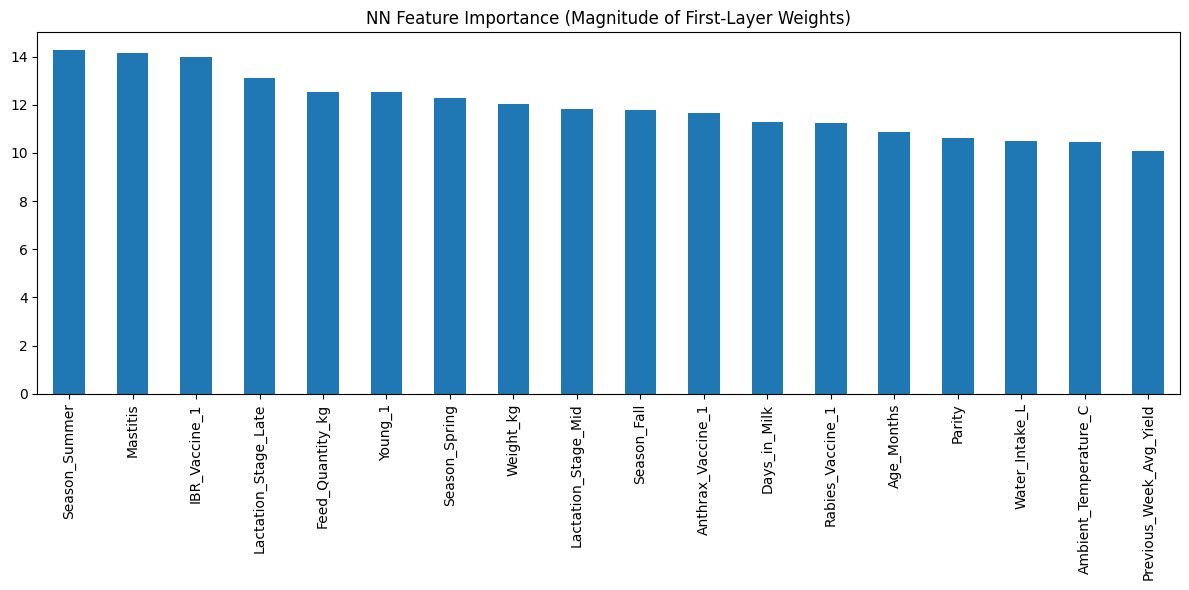

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

first_layer = model.coefs_[0]
importance = np.sum(np.abs(first_layer), axis=1)

feature_importance = pd.Series(importance, index=X_train_full.columns)
feature_importance.sort_values(ascending=False, inplace=True)
print(feature_importance)

feature_importance.plot(kind="bar", figsize=(12,6), title="NN Feature Importance (Magnitude of First-Layer Weights)")
plt.tight_layout()
plt.show()

Computing permutation importance...
Season_Fall                0.009434
Season_Spring              0.011374
Ambient_Temperature_C      0.014363
Previous_Week_Avg_Yield    0.019613
Days_in_Milk               0.029337
Rabies_Vaccine_1           0.031991
Anthrax_Vaccine_1          0.032301
Lactation_Stage_Mid        0.033634
IBR_Vaccine_1              0.035085
Lactation_Stage_Late       0.066718
Mastitis                   0.113855
Water_Intake_L             0.118805
Young_1                    0.211411
Age_Months                 0.213844
Season_Summer              0.230124
Feed_Quantity_kg           0.331266
Parity                     0.378317
Weight_kg                  0.602124
dtype: float64


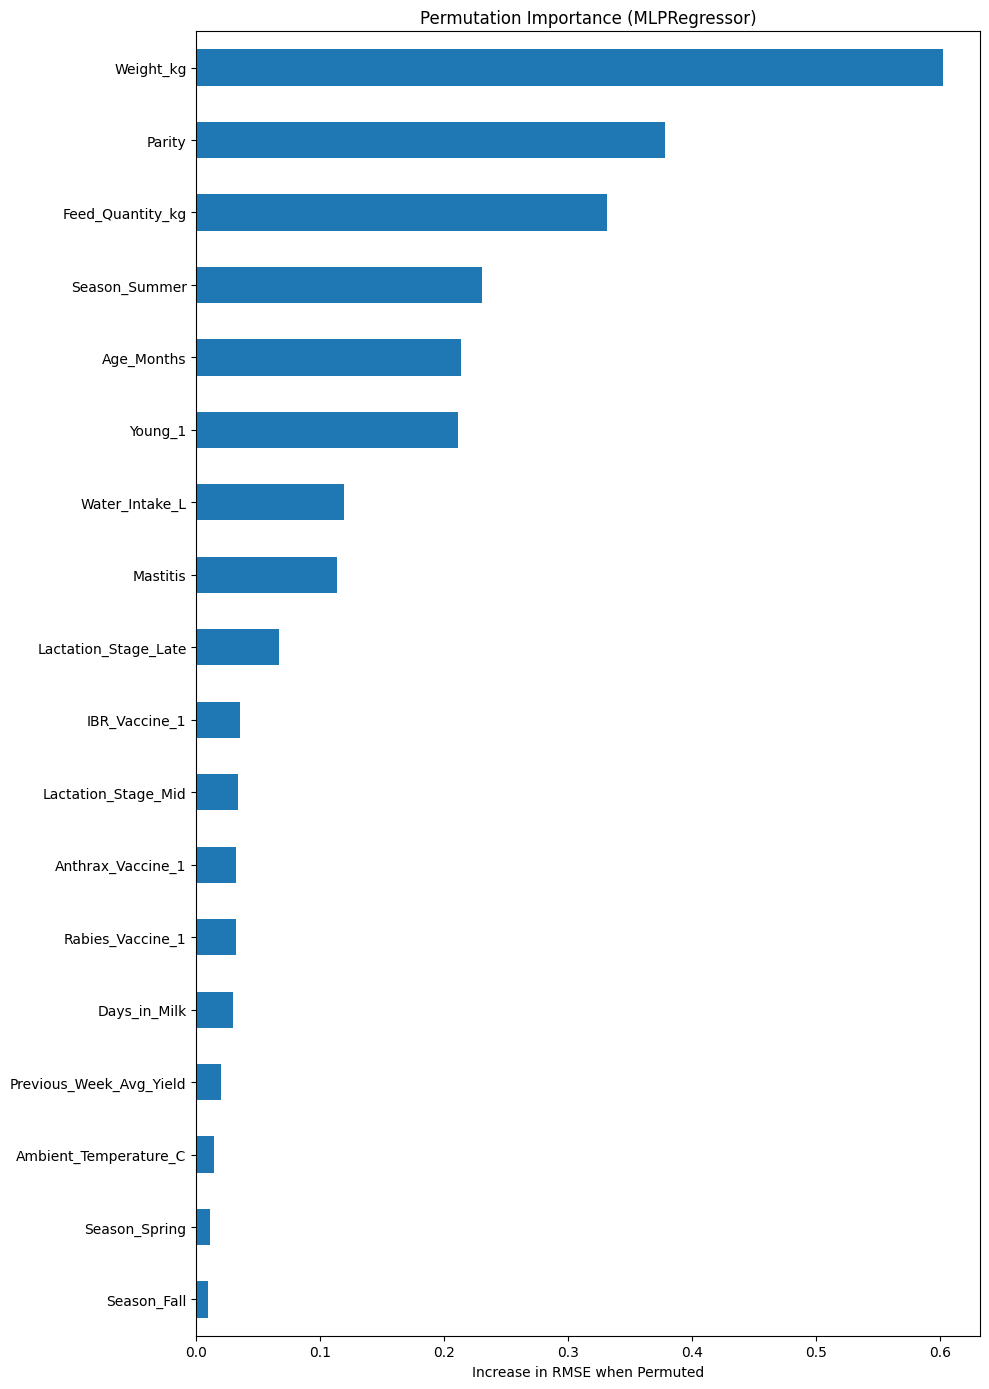

In [9]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# --------------------------------------------------------------
# Assume you already have:
# model               -> trained MLPRegressor
# X_train_full        -> DataFrame
# y_train_full        -> Series or array
# --------------------------------------------------------------

print("Computing permutation importance...")

# Compute permutation importance (10 repeats is typical)
result = permutation_importance(
    model,
    X_train_full,
    Y_train,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

# Extract importance values
importances = pd.Series(result.importances_mean, index=X_train_full.columns)
importances_sorted = importances.sort_values(ascending=True)

print(importances_sorted)

# --------------------------------------------------------------
# PLOT
# --------------------------------------------------------------
plt.figure(figsize=(10, 14))
importances_sorted.plot(kind='barh')
plt.title("Permutation Importance (MLPRegressor)")
plt.xlabel("Increase in RMSE when Permuted")
plt.tight_layout()
plt.show()

In [10]:
# Ensemble predictions
print ("Generating ensemble predictions...")
ensemble_preds = []
X_train = pd.read_csv (TRAIN_PATH).drop (TARGET_FEATURE, axis = 1)
X_test = pd.read_csv (TEST_PATH)


for fold_model, fold_scaler in zip (fold_models, fold_scalers):
    temp, X_test_proc, _ = preprocess (X_train.copy (),
                                    X_test.copy (),
                                    scaler = fold_scaler)
    fold_pred = fold_model.predict (X_test_proc)
    ensemble_preds.append (fold_pred)

    train_pred = fold_model.predict (temp)
    rmse = np.sqrt (mean_squared_error (train_pred, Y_train))
    print (f"Train RMSE: {rmse}")


y_pred_ensemble = np.mean (ensemble_preds, axis = 0)

print (f"Ensemble pred mean: {y_pred_ensemble.mean ():.5f}")
print (f"Training label mean: {Y_train.mean ():.5f}")


out_data = pd.DataFrame ({'Cattle_ID': np.arange (1, len (y_pred_ensemble) + 1),
                          'Milk_Yield_L': y_pred_ensemble})
out_data.to_csv (OUT_PATH, index = False)

Generating ensemble predictions...
Train RMSE: 4.103716970144751
Train RMSE: 4.103671981067283
Train RMSE: 4.102769348471257
Train RMSE: 4.104115224142294
Train RMSE: 4.103478323646582
Train RMSE: 4.101801981582394
Ensemble pred mean: 15.62390
Training label mean: 15.58916
